# Options Pricer: Walkthrough
Black-Scholes, Monte Carlo and binomial tree pricing, Greeks, implied volatility and the volatility smile.
Benchmark inputs: S = K = 100, T = 1, r = 5%, σ = 20%.

In [1]:
import sys
sys.path.insert(0, "../src")

%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from black_scholes import *
from monte_carlo import monte_carlo_call_price, monte_carlo_put_price, convergence_data
from binomial_tree import binomial_tree_price, plot_binomial_convergence

S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2

In [2]:
call = black_scholes_call(S, K, T, r, sigma)
put = black_scholes_put(S, K, T, r, sigma)
print(f"Call: {call:.4f}   Put: {put:.4f}")
print(f"C - P = {call - put:.4f}   S - K*exp(-rT) = {S - K*np.exp(-r*T):.4f}")

Call: 10.4506   Put: 5.5735
C - P = 4.8771   S - K*exp(-rT) = 4.8771


## 1. Black-Scholes and put-call parity

In [3]:
call = black_scholes_call(S, K, T, r, sigma)
put = black_scholes_put(S, K, T, r, sigma)
print(f"Call: {call:.4f}   Put: {put:.4f}")
print(f"C - P = {call - put:.4f}   S - K*exp(-rT) = {S - K*np.exp(-r*T):.4f}")

Call: 10.4506   Put: 5.5735
C - P = 4.8771   S - K*exp(-rT) = 4.8771


## 2. Greeks: analytical vs finite difference

In [4]:
print(f"Delta: {delta_call(S,K,T,r,sigma):.6f} vs {delta_call_finite_diff(S,K,T,r,sigma):.6f}")
print(f"Gamma: {gamma(S,K,T,r,sigma):.6f} vs {gamma_finite_diff(S,K,T,r,sigma):.6f}")
print(f"Vega:  {vega(S,K,T,r,sigma):.6f} vs {vega_finite_diff(S,K,T,r,sigma):.6f}")
print(f"Theta: {theta_call(S,K,T,r,sigma):.6f} vs {theta_call_finite_diff(S,K,T,r,sigma):.6f}")

Delta: 0.636831 vs 0.636831
Gamma: 0.018762 vs 0.018762
Vega:  0.375240 vs 0.375210
Theta: -0.017573 vs -0.017573


## 3. Monte Carlo convergence

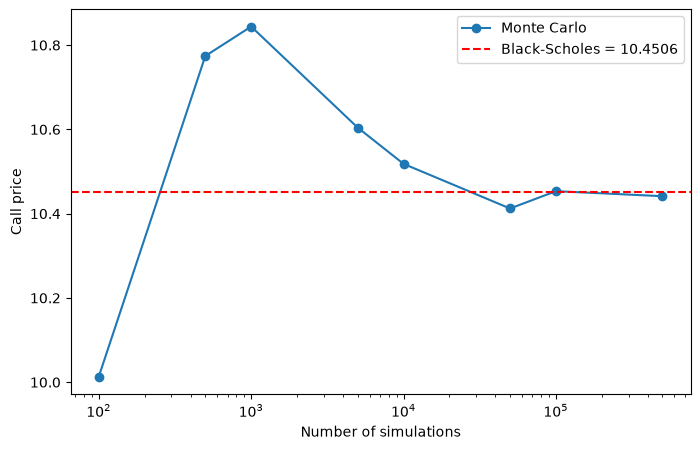

In [5]:
sim_counts = [100, 500, 1000, 5000, 10000, 50000, 100000, 500000]
mc_prices = convergence_data(S, K, T, r, sigma, sim_counts)

plt.figure(figsize=(8, 5))
plt.plot(sim_counts, mc_prices, marker="o", label="Monte Carlo")
plt.axhline(call, color="r", linestyle="--", label=f"Black-Scholes = {call:.4f}")
plt.xscale("log")
plt.xlabel("Number of simulations")
plt.ylabel("Call price")
plt.legend()
plt.show()

## 4. Binomial tree: European vs American

In [6]:
for opt in ("call", "put"):
    eu = binomial_tree_price(S, K, T, r, sigma, 1000, opt)
    am = binomial_tree_price(S, K, T, r, sigma, 1000, opt, american=True)
    print(f"{opt}: European {eu:.4f}   American {am:.4f}")

call: European 10.4486   American 10.4486
put: European 5.5715   American 6.0896


Saved plots/binomial_convergence.png


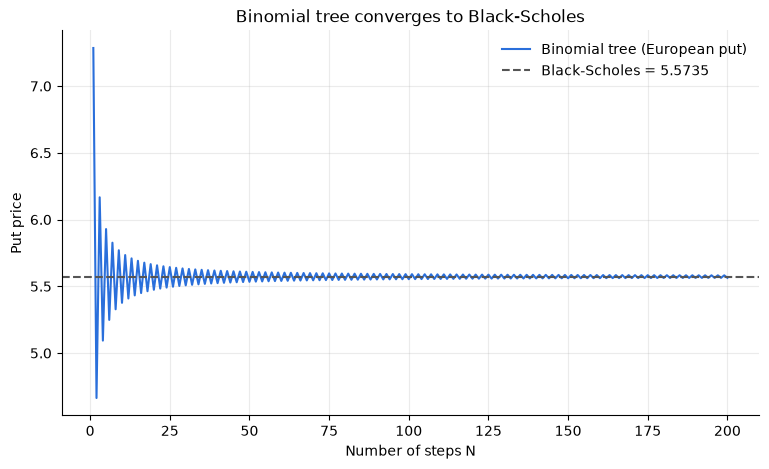

In [7]:
_ = plot_binomial_convergence(S, K, T, r, sigma)

## 5. Volatility smile and a real option (TSLA)

TSLA: spot 375.00, expiry 2027-09-17, T = 0.937, ATM implied vol = 0.4493
Saved plots/volatility_smile_TSLA.png


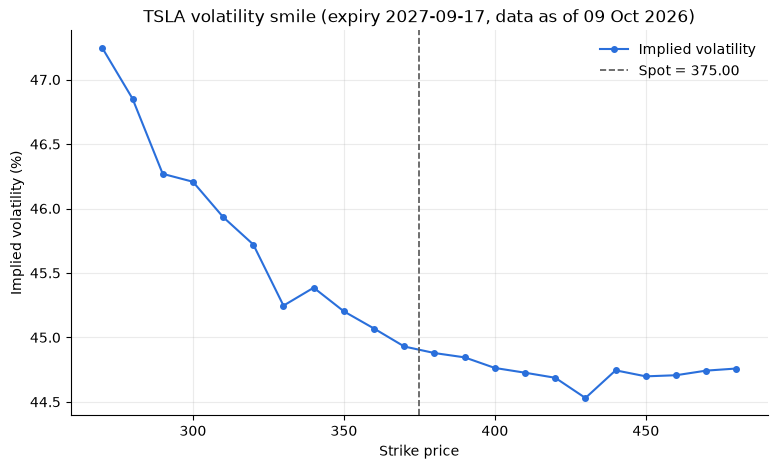

In [8]:
from volatility_smile import (get_option_chain, time_to_expiry, calculate_implied_vols,
                              atm_implied_vol, plot_volatility_smile, RISK_FREE_RATE)

ticker = "TSLA"
calls, spot, expiry = get_option_chain(ticker, target_days=365)
T_mkt = time_to_expiry(expiry)
iv_table = calculate_implied_vols(calls, spot, T_mkt, RISK_FREE_RATE)
K_atm, sigma_atm = atm_implied_vol(iv_table, spot)
print(f"{ticker}: spot {spot:.2f}, expiry {expiry}, T = {T_mkt:.3f}, ATM implied vol = {sigma_atm:.4f}")
_ = plot_volatility_smile(iv_table, spot, ticker, expiry)

In [9]:
r_mkt = RISK_FREE_RATE
rows = {
    "Black-Scholes": (black_scholes_call(spot, K_atm, T_mkt, r_mkt, sigma_atm),
                      black_scholes_put(spot, K_atm, T_mkt, r_mkt, sigma_atm)),
    "Binomial tree": (binomial_tree_price(spot, K_atm, T_mkt, r_mkt, sigma_atm, 1000, "call"),
                      binomial_tree_price(spot, K_atm, T_mkt, r_mkt, sigma_atm, 1000, "put")),
    "Monte Carlo": (monte_carlo_call_price(spot, K_atm, T_mkt, r_mkt, sigma_atm, 500_000),
                    monte_carlo_put_price(spot, K_atm, T_mkt, r_mkt, sigma_atm, 500_000)),
    "Binomial, American": (binomial_tree_price(spot, K_atm, T_mkt, r_mkt, sigma_atm, 1000, "call", True),
                           binomial_tree_price(spot, K_atm, T_mkt, r_mkt, sigma_atm, 1000, "put", True)),
}
print(f"{'Method':<22}{'Call':>10}{'Put':>10}")
for name, (c, p) in rows.items():
    print(f"{name:<22}{c:>10.4f}{p:>10.4f}")

Method                      Call       Put
Black-Scholes            74.2250   52.2905
Binomial tree            74.2399   52.3054
Monte Carlo              74.2825   52.2978
Binomial, American       74.2399   54.0144
